In [2]:
!pip install xgboost


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [4]:
df_inicial = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')

In [5]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [6]:
# renomeando as colunas

df_inicial = df_inicial.rename(columns={'Gender':'genero',
                                        'Age': 'idade',
                                        'Height': 'altura',
                                        'Weight': 'peso',
                                        'family_history_with_overweight': 'historico_familiar',
                                        'FAVC': 'comidas_cal_freq',
                                        'FCVC':  'vegetais_refeicoes',
                                        'NCP': 'refeicoes_diarias',
                                        'CAEC': 'comidas_entre_refeicoes',
                                        'SMOKE': 'fumante',
                                        'CH2O': 'consumo_agua',
                                        'SCC': 'controle_calorias',
                                        'FAF': 'frequencia_atv_fisica',
                                        'TUE': 'tempo_uso_tecnologia',
                                        'CALC': 'frequencia_alcool',
                                        'MTRANS': 'metodo_transporte',
                                        'NObeyesdad': 'nivel_obesidade'
                                        })

In [7]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   genero                   2111 non-null   object 
 1   idade                    2111 non-null   float64
 2   altura                   2111 non-null   float64
 3   peso                     2111 non-null   float64
 4   historico_familiar       2111 non-null   object 
 5   comidas_cal_freq         2111 non-null   object 
 6   vegetais_refeicoes       2111 non-null   float64
 7   refeicoes_diarias        2111 non-null   float64
 8   comidas_entre_refeicoes  2111 non-null   object 
 9   fumante                  2111 non-null   object 
 10  consumo_agua             2111 non-null   float64
 11  controle_calorias        2111 non-null   object 
 12  frequencia_atv_fisica    2111 non-null   float64
 13  tempo_uso_tecnologia     2111 non-null   float64
 14  frequencia_alcool       

In [8]:
df_inicial.head()

,genero,idade,altura,peso,historico_familiar,comidas_cal_freq,vegetais_refeicoes,refeicoes_diarias,comidas_entre_refeicoes,fumante,consumo_agua,controle_calorias,frequencia_atv_fisica,tempo_uso_tecnologia,frequencia_alcool,metodo_transporte,nivel_obesidade
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [9]:
df_inicial['nivel_obesidade'].value_counts()

,count
nivel_obesidade,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


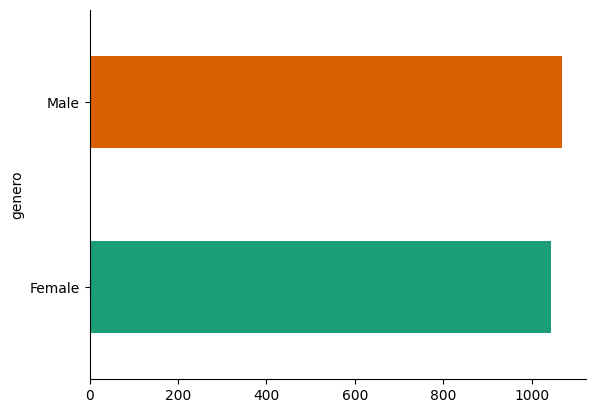

In [10]:
# @title genero

from matplotlib import pyplot as plt
import seaborn as sns
df_inicial.groupby('genero').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

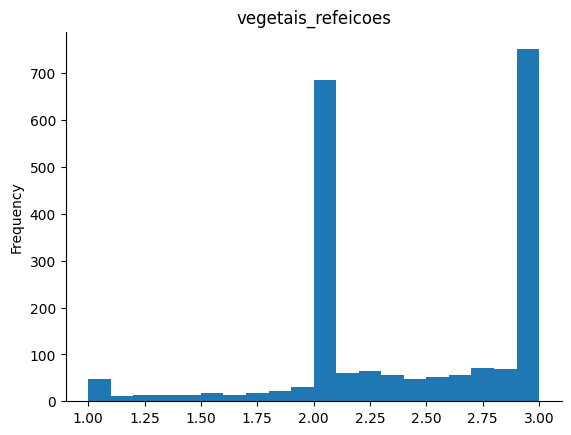

In [11]:
# @title vegetais_refeicoes

from matplotlib import pyplot as plt
df_inicial['vegetais_refeicoes'].plot(kind='hist', bins=20, title='vegetais_refeicoes')
plt.gca().spines[['top', 'right',]].set_visible(False)

### Redefinição de variáveis para numérico

In [12]:
# redefinir intervalo de vegetais_refeicoes
df_inicial['vegetais_refeicoes_trat'] = np.round(df_inicial['vegetais_refeicoes'])

# Converter a coluna para o tipo inteiro
df_inicial['vegetais_refeicoes_trat'] = df_inicial['vegetais_refeicoes_trat'].astype(int)

In [13]:
# redefinir famale = 0 e male = 1
df_inicial['genero_trat'] = df_inicial['genero'].map({'Female': 0, 'Male': 1})

# Converter a coluna para o tipo inteiro
df_inicial['genero_trat'] = df_inicial['genero_trat'].astype(int)

In [14]:
# redefinir historico_familiar_trat = yes para 1 e historico_familiar_trat = no para 0
df_inicial['historico_familiar_trat'] = df_inicial['historico_familiar'].map({'no': 0, 'yes': 1})

# Converter a coluna para o tipo inteiro
df_inicial['historico_familiar_trat'] = df_inicial['historico_familiar_trat'].astype(int)

In [15]:
# redefinir fumante_trat = yes para 1 e fumante_trat = no para 0
df_inicial['fumante_trat'] = df_inicial['fumante'].map({'no': 0, 'yes': 1})

# Converter a coluna para o tipo inteiro
df_inicial['fumante_trat'] = df_inicial['fumante_trat'].astype(int)

In [16]:
# redefinir intervalo de frequencia_atv_fisica
df_inicial['frequencia_atv_fisica_trat'] = np.round(df_inicial['frequencia_atv_fisica'])

# Converter a coluna para o tipo inteiro
df_inicial['frequencia_atv_fisica_trat'] = df_inicial['frequencia_atv_fisica_trat'].astype(int)

In [17]:
# redefinir intervalo de tempo_uso_tecnologia
df_inicial['tempo_uso_tecnologia_trat'] = np.round(df_inicial['tempo_uso_tecnologia'])

# Converter a coluna para o tipo inteiro
df_inicial['tempo_uso_tecnologia_trat'] = df_inicial['tempo_uso_tecnologia_trat'].astype(int)

In [18]:
# redefinir intervalo de consumo_agua
df_inicial['consumo_agua_trat'] = np.round(df_inicial['consumo_agua'])

# Converter a coluna para o tipo inteiro
df_inicial['consumo_agua_trat'] = df_inicial['consumo_agua_trat'].astype(int)

In [19]:
# redefinir comidas_cal_freq_trat = yes para 1 e comidas_cal_freq_trat = no para 0
df_inicial['comidas_cal_freq_trat'] = df_inicial['comidas_cal_freq'].map({'no': 0, 'yes': 1})

# Converter a coluna para o tipo inteiro
df_inicial['comidas_cal_freq_trat'] = df_inicial['comidas_cal_freq_trat'].astype(int)

In [20]:
# redefinir nivel_obesidade para inteiros
df_inicial['nivel_obesidade_trat'] = df_inicial['nivel_obesidade'].map({'Insufficient_Weight': 0,
                                                                          'Normal_Weight': 1,
                                                                          'Overweight_Level_I': 2,
                                                                          'Overweight_Level_II': 3,
                                                                          'Obesity_Type_I': 4,
                                                                          'Obesity_Type_II': 5,
                                                                          'Obesity_Type_III': 6})
# Converter a coluna para o tipo inteiro
df_inicial['nivel_obesidade_trat'] = df_inicial['nivel_obesidade_trat'].astype(int)

In [21]:
df_inicial['IMC'] = df_inicial['peso'] / (df_inicial['altura'] ** 2)

In [22]:
px.box(df_inicial, x='nivel_obesidade',y='IMC', color='genero')

### Gráficos interessantes

<Axes: xlabel='peso', ylabel='nivel_obesidade'>

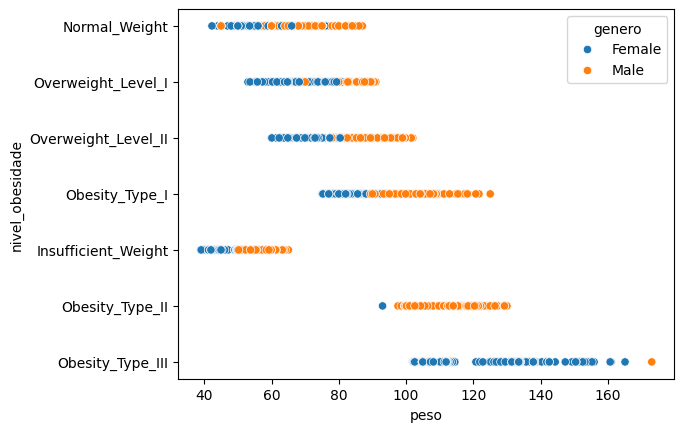

In [23]:
sns.scatterplot(data = df_inicial, x=df_inicial.columns[3], y= df_inicial.columns[16], hue = 'genero')

In [24]:
px.box(df_inicial,x= 'nivel_obesidade',y='peso', color='genero')

In [25]:
px.box(df_inicial,x= 'nivel_obesidade',y='idade')

#### Tratamentos no df_inicial

In [26]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   genero                      2111 non-null   object 
 1   idade                       2111 non-null   float64
 2   altura                      2111 non-null   float64
 3   peso                        2111 non-null   float64
 4   historico_familiar          2111 non-null   object 
 5   comidas_cal_freq            2111 non-null   object 
 6   vegetais_refeicoes          2111 non-null   float64
 7   refeicoes_diarias           2111 non-null   float64
 8   comidas_entre_refeicoes     2111 non-null   object 
 9   fumante                     2111 non-null   object 
 10  consumo_agua                2111 non-null   float64
 11  controle_calorias           2111 non-null   object 
 12  frequencia_atv_fisica       2111 non-null   float64
 13  tempo_uso_tecnologia        2111 

In [27]:
df = df_inicial[["genero_trat", "idade", "altura", "peso",
                 "historico_familiar_trat", "vegetais_refeicoes_trat", "refeicoes_diarias", "comidas_cal_freq_trat",
                 "consumo_agua_trat", "frequencia_atv_fisica_trat", "tempo_uso_tecnologia_trat", "fumante_trat", "nivel_obesidade_trat", "IMC"]]

In [28]:
# relembrando 'Female': 0, 'Male': 1
df.head()

,genero_trat,idade,altura,peso,historico_familiar_trat,vegetais_refeicoes_trat,refeicoes_diarias,comidas_cal_freq_trat,consumo_agua_trat,frequencia_atv_fisica_trat,tempo_uso_tecnologia_trat,fumante_trat,nivel_obesidade_trat,IMC
0,0,21.0,1.62,64.0,1,2,3.0,0,2,0,1,0,1,24.386526
1,0,21.0,1.52,56.0,1,3,3.0,0,3,3,0,1,1,24.238227
2,1,23.0,1.80,77.0,1,2,3.0,0,2,2,1,0,1,23.765432
3,1,27.0,1.80,87.0,0,3,3.0,0,2,2,0,0,2,26.851852
4,1,22.0,1.78,89.8,0,2,1.0,0,2,0,0,0,3,28.342381


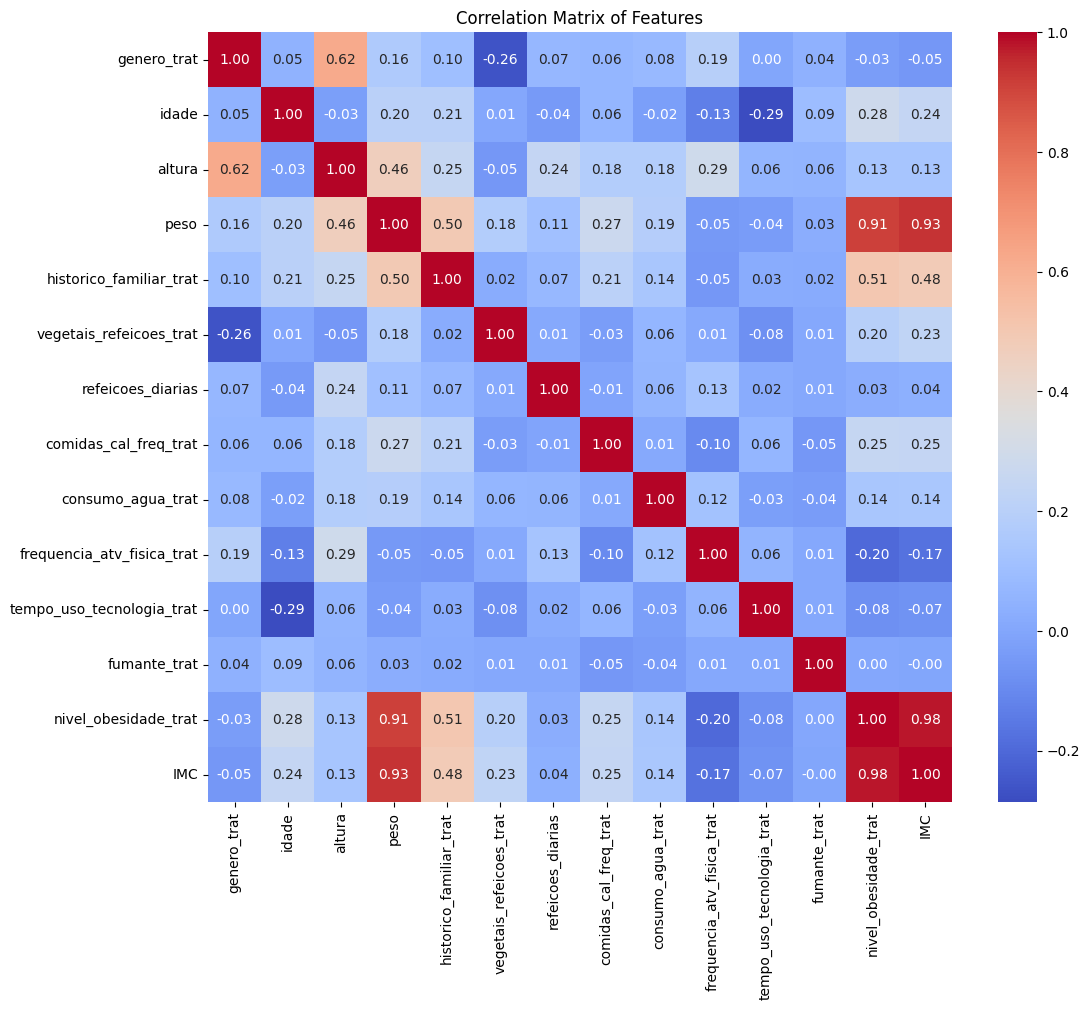

In [29]:
# prompt: mapa de correlação para o df

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [30]:
# prompt: import xgboost
import xgboost as xgb


### Início do modelo - cópia do Penguins (rever)

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [32]:
# df de treino e df de teste A

dftrain, dftest = train_test_split(df ,test_size=0.3, random_state=42)


In [33]:
dftrain.columns, dftest.columns

(Index(['genero_trat', 'idade', 'altura', 'peso', 'historico_familiar_trat',
        'vegetais_refeicoes_trat', 'refeicoes_diarias', 'comidas_cal_freq_trat',
        'consumo_agua_trat', 'frequencia_atv_fisica_trat',
        'tempo_uso_tecnologia_trat', 'fumante_trat', 'nivel_obesidade_trat',
        'IMC'],
       dtype='object'),
 Index(['genero_trat', 'idade', 'altura', 'peso', 'historico_familiar_trat',
        'vegetais_refeicoes_trat', 'refeicoes_diarias', 'comidas_cal_freq_trat',
        'consumo_agua_trat', 'frequencia_atv_fisica_trat',
        'tempo_uso_tecnologia_trat', 'fumante_trat', 'nivel_obesidade_trat',
        'IMC'],
       dtype='object'))

In [34]:
# Treinando o modelo

obesidade_classificacao = RandomForestClassifier(random_state=42,n_estimators = 10)

In [35]:
df.head(1)

,genero_trat,idade,altura,peso,historico_familiar_trat,vegetais_refeicoes_trat,refeicoes_diarias,comidas_cal_freq_trat,consumo_agua_trat,frequencia_atv_fisica_trat,tempo_uso_tecnologia_trat,fumante_trat,nivel_obesidade_trat,IMC
0,0,21.0,1.62,64.0,1,2,3.0,0,2,0,1,0,1,24.386526


In [36]:
# Variáveis interessantes para o modelo
variaveis_train = ['genero_trat', 'altura', 'historico_familiar_trat', 'IMC', 'peso']


In [37]:
X_train= dftrain[variaveis_train]
y_train = dftrain['nivel_obesidade_trat']


In [38]:
obesidade_classificacao.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [39]:
# Função que mostra o peso que as variáveis possui no modelo
obesidade_classificacao.feature_importances_

array([0.08653233, 0.03698226, 0.0174703 , 0.61512047, 0.24389464])

In [40]:
obesidade_classificacao.score(X_train, y_train)

1.0

In [41]:
X_test = dftest[variaveis_train]
y_test = dftest['nivel_obesidade_trat']

In [42]:
y_pred = obesidade_classificacao.predict(X_test)

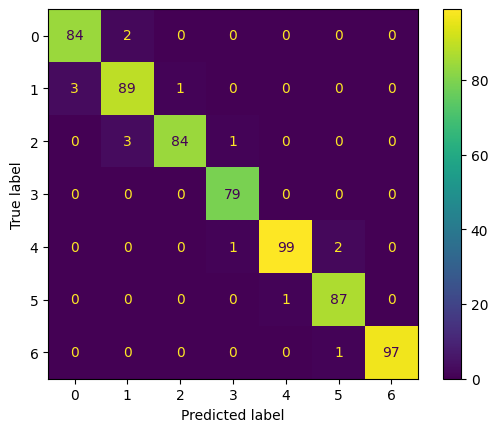

In [43]:
cm = confusion_matrix(y_test, y_pred)
plot = ConfusionMatrixDisplay(cm)
plot.plot()